In [24]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score,silhouette_score,calinski_harabasz_score
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [13]:
#2. data collection
iris_data = load_iris()
iris_dataset = pd.DataFrame(data = iris_data.data, columns = iris_data.feature_names )
iris_dataset

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
#3. Data understanding
print(iris_dataset.shape)
print("===========================")
print(iris_dataset.dtypes)
print("===========================")
print(iris_dataset.isna().sum())
("===========================")
iris_dataset.describe()


(150, 4)
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [20]:
# 4. Data preprocessing
#transforming data
standard_scaled = StandardScaler()
scaled_iris_dataset = standard_scaled.fit_transform(iris_dataset)
scaled_iris_dataset = pd.DataFrame(scaled_iris_dataset)
scaled_iris_dataset

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [27]:
#clustering
kmeans_test = KMeans()
wcss = []
sihouette_scores = []
calinski_harabasz_scores = []
for i in range(2,5):
    k_means_test = KMeans(n_clusters=i,random_state=234)
    cluster_labels = k_means_test.fit_predict(scaled_iris_dataset)
    wcss.append(k_means_test.inertia_)
    sihouette_scores.append(silhouette_score(scaled_iris_dataset,cluster_labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(scaled_iris_dataset,cluster_labels))

print(sihouette_scores.index(max(sihouette_scores)))
print(calinski_harabasz_scores.index(max(calinski_harabasz_scores)))

0
0


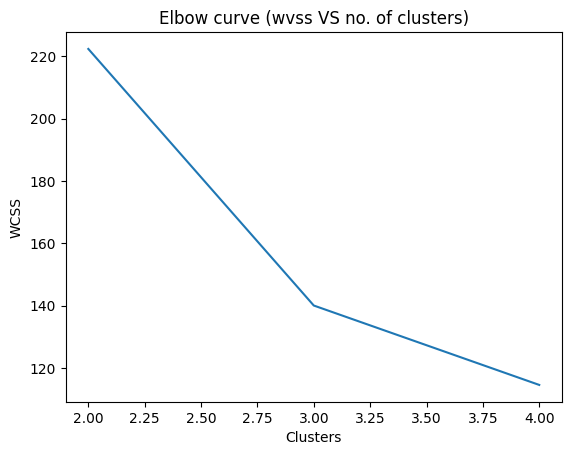

In [26]:
#Elbow curve
plt.plot(range(2,5),wcss)
plt.title(label='Elbow curve (wvss VS no. of clusters)')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [32]:
kmeans = KMeans(n_clusters=3,random_state=123)
clusters_classified = kmeans.fit_predict(scaled_iris_dataset)
iris_dataset["classification"] = clusters_classified
iris_dataset

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),classification
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


In [35]:
# Data mining
iris_dataset.groupby("classification").agg(['mean','min','max'])

sepal length (cm)           sepal width (cm)            \
                            mean  min  max             mean  min  max   
classification                                                          
0                       6.780851  5.9  7.9         3.095745  2.5  3.8   
1                       5.006000  4.3  5.8         3.428000  2.3  4.4   
2                       5.801887  4.9  6.6         2.673585  2.0  3.0   

               petal length (cm)           petal width (cm)            
                            mean  min  max             mean  min  max  
classification                                                         
0                       5.510638  4.4  6.9         1.972340  1.4  2.5  
1                       1.462000  1.0  1.9         0.246000  0.1  0.6  
2                       4.369811  3.0  5.6         1.413208  1.0  2.4